# bgc-infiller EDA - Análisis exploratorio de datos

In [1]:
%cd ..

a:\IA\TFM\bgc-infiller


C:\Users\lmjim\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd

baseline_mapping = {
    'bgc-infiller-esm2-v1.5.0': 'baseline-esm2_t6_8M',
    'bgc-infiller-esm2-v2.5.0': 'baseline-esm2_t12_35M'
}

df = pd.read_csv('./eval_results/evaluation_results.csv')
df_base = pd.read_csv('./eval_results/baseline_results.csv')

df_base['model_name_version'] = df_base['model_name_version'].replace(baseline_mapping)
df = pd.concat([df, df_base], ignore_index=True)
df

,model_name_version,eval_loss,perplexity,eval_runtime,eval_masked_token_accuracy,eval_n_masked_tokens
0,bgc-infiller-esm2-v1.0.0,1.603875,4.972264,582.6622,0.509520,400620
1,bgc-infiller-esm2-v1.5.0,1.561883,4.767791,582.4346,0.525356,669215
2,bgc-infiller-esm2-v2.0.0,1.583035,4.869715,562.4310,0.519527,669215
3,bgc-infiller-esm2-v2.5.0,1.350123,3.857900,1394.0560,0.584967,669215
4,baseline-esm2_t6_8M,2.255970,9.544542,532.0499,0.346276,669215
5,baseline-esm2_t12_35M,1.894539,6.649481,1323.9566,0.430760,669215


C:\Users\lmjim\AppData\Local\Temp\ipykernel_29884\3219666464.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


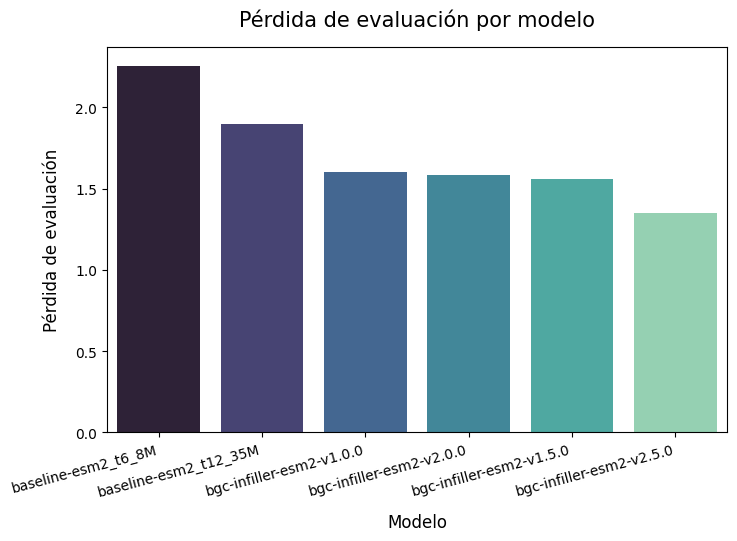

C:\Users\lmjim\AppData\Local\Temp\ipykernel_29884\3219666464.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


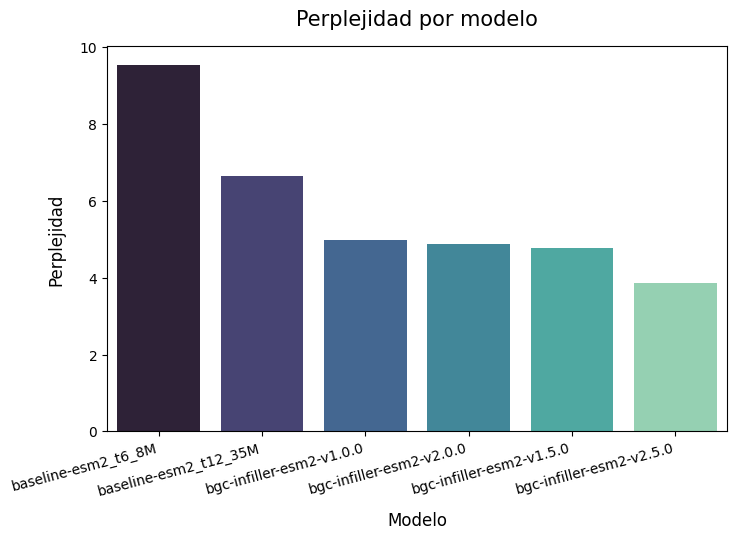

C:\Users\lmjim\AppData\Local\Temp\ipykernel_29884\3219666464.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


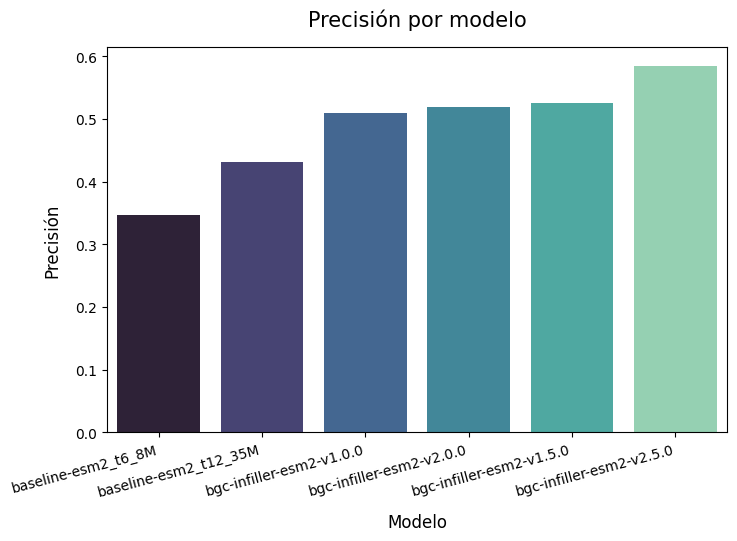

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = [
    ('eval_loss', 'Pérdida de evaluación'),
    ('perplexity', 'Perplejidad'),
    ('eval_masked_token_accuracy', 'Precisión')
]

for m in metrics:
  if m[1] == 'Precisión':
    ascending=True
  else:
    ascending=False

  df_ordenado = df.sort_values(by=m[0], ascending=ascending)

  plt.figure(figsize=(8, 5))
  sns.barplot(
      x='model_name_version',
      y=m[0],
      data=df_ordenado,
      palette='mako'
  )

  plt.title(f"{m[1]} por modelo", fontsize=15, pad=15)
  plt.xlabel('Modelo', fontsize=12, labelpad=10)
  plt.ylabel(m[1], fontsize=12, labelpad=10)
  plt.xticks(rotation=15, ha='right')

  plt.show()